# Data Analysis (cavity_claw_RouteMeander_eigenmode)

## Configuration

Disable cell scrolling.

Parameters are stored in a shared script.

In [78]:
from parameters import *
os.makedirs('scalers', exist_ok=True)
os.makedirs(f'{DATA_DIR}', exist_ok=True)
os.makedirs(f'{DATA_DIR}/npy', exist_ok=True)

## Library

In [79]:
import json
import numpy as np
import pandas as pd
from pandas import json_normalize
from sklearn.preprocessing import MinMaxScaler
import joblib

## Datasets

### Load

From https://huggingface.co/datasets/SQuADDS/SQuADDS_DB/tree/main

In [80]:
import pandas as pd

df = pd.read_json("cavity_claw-RouteMeander-eigenmode.json")

In [81]:
#dropping datasets where design.resonator_type is "half"
mask = df["design"].apply(
    lambda d: str(d.get("resonator_type", "")).strip().lower() != "half"
)

df = df.loc[mask].reset_index(drop=True)

print("Remaining rows:", len(df))
print("Removed rows:", (~mask).sum())
print("Remaining resonator types:\n",
      df["design"].apply(lambda d: d.get("resonator_type", None)).value_counts(dropna=False))

Remaining rows: 810
Removed rows: 406
Remaining resonator types:
 design
quarter    810
Name: count, dtype: int64


### Look at the data and structure

In [82]:
#look at the first value
first_entry = df.iloc[100]

# Print the headers and their corresponding values
for header, value in first_entry.items():
    print(f"{header}: {value}")

sim_options: {'setup': {'name': 'Setup', 'reuse_selected_design': True, 'reuse_setup': True, 'min_freq_ghz': 1, 'n_modes': 1, 'max_delta_f': 0.05, 'max_passes': 50, 'min_passes': 1, 'min_converged': 1, 'pct_refinement': 30, 'basis_order': 1, 'vars': {'Lj': '0nH', 'Cj': '0fF'}, 'min_converged_passes': 2}, 'simulator': 'Ansys HFSS'}
sim_results: {'cavity_frequency': 5987186143.809999, 'kappa': 22053.7288176, 'units': 'Hz'}
design: {'design_options': {'claw_opts': {'connection_pads': {'readout': {'connector_location': '90', 'connector_type': '0', 'claw_length': '440um', 'ground_spacing': '4.1um', 'claw_gap': '5.1um', 'claw_width': '15um', 'claw_cpw_width': '11.7um', 'claw_cpw_length': '0um'}}, 'orientation': '-90', 'pos_x': '-1500um', 'cross_length': '0um', 'cross_width': '0um', 'cross_gap': '0um'}, 'cpw_opts': {'fillet': '49.9um', 'total_length': '3900um', 'trace_width': '11.7um', 'trace_gap': '5.1um', 'lead': {'start_straight': '50um'}, 'pin_inputs': {'start_pin': {'component': 'cplr', 

In [83]:
#Look at the headers relevant for us, to start lets only look at the sim_results (our x data) and design (our y data)
sim_results_column = df['sim_results']
print(sim_results_column, '\n\n')

design_column = df['design']
print(design_column)

0      {'cavity_frequency': 5353549772.64, 'kappa': 1...
1      {'cavity_frequency': 8399240836.29, 'kappa': 2...
2      {'cavity_frequency': 8694844797.89, 'kappa': 2...
3      {'cavity_frequency': 6616574393.559999, 'kappa...
4      {'cavity_frequency': 7986835171.7, 'kappa': 20...
                             ...                        
805    {'cavity_frequency': 7489688801.09, 'kappa': 4...
806    {'cavity_frequency': 7452442461.75, 'kappa': 3...
807    {'cavity_frequency': 7415826341.76, 'kappa': 4...
808    {'cavity_frequency': 7378752058.07, 'kappa': 4...
809    {'cavity_frequency': 7342036181.17, 'kappa': 5...
Name: sim_results, Length: 810, dtype: object 


0      {'design_options': {'claw_opts': {'connection_...
1      {'design_options': {'claw_opts': {'connection_...
2      {'design_options': {'claw_opts': {'connection_...
3      {'design_options': {'claw_opts': {'connection_...
4      {'design_options': {'claw_opts': {'connection_...
                             ...       

In [84]:
#take a look at everything in the design dataset
#flatten what will be our y data
#Makes each row correspond to one element of df['design']
#If a particular row's dict doesn’t have that key, it fills in NaN
design_flat = json_normalize(df['design'])

# List all column headers
design_column_vals = design_flat.columns.tolist()
print(design_column_vals)
print('length: ',len(design_column_vals))

['coupler_type', 'resonator_type', 'design_tool', 'design_options.claw_opts.connection_pads.readout.connector_location', 'design_options.claw_opts.connection_pads.readout.connector_type', 'design_options.claw_opts.connection_pads.readout.claw_length', 'design_options.claw_opts.connection_pads.readout.ground_spacing', 'design_options.claw_opts.connection_pads.readout.claw_gap', 'design_options.claw_opts.connection_pads.readout.claw_width', 'design_options.claw_opts.connection_pads.readout.claw_cpw_width', 'design_options.claw_opts.connection_pads.readout.claw_cpw_length', 'design_options.claw_opts.orientation', 'design_options.claw_opts.pos_x', 'design_options.claw_opts.cross_length', 'design_options.claw_opts.cross_width', 'design_options.claw_opts.cross_gap', 'design_options.cpw_opts.fillet', 'design_options.cpw_opts.total_length', 'design_options.cpw_opts.trace_width', 'design_options.cpw_opts.trace_gap', 'design_options.cpw_opts.lead.start_straight', 'design_options.cpw_opts.pin_inp

In [85]:
# first n values from the column
for v in design_flat["design_options.cplr_opts.coupling_length"].iloc[500:510]:
    print(v)

230um
230um
350um
350um
350um
350um
350um
350um
350um
350um


### Reformat

In [86]:
#flatten what will be our X data
X = json_normalize(df['sim_results'])
# Dropping the 'units' column for now because i think they are al in Hz and this info isnt useful
X = X.drop(columns=['units'])
print(X)

     cavity_frequency          kappa
0        5.353550e+09  161106.598429
1        8.399241e+09  268412.116632
2        8.694845e+09  255873.654612
3        6.616574e+09   30459.761161
4        7.986835e+09  208304.221064
..                ...            ...
805      7.489689e+09   46004.713078
806      7.452442e+09   38837.211205
807      7.415826e+09   46696.417529
808      7.378752e+09   41526.048615
809      7.342036e+09   58463.648381

[810 rows x 2 columns]


In [87]:
#flatten what will be our y data
#Makes each row correspond to one element of df['design']
#If a particular row's dict doesn’t have that key, it fills in NaN
y = json_normalize(df['design'])

#get rid of this column because there are two spellings in the dataset that will confuse the NN. We always just use Qiskit, so for now we dont need this
y = y.drop(columns=['design_options.claw_opts.connection_pads.readout.connector_location',
 'design_options.claw_opts.connection_pads.readout.connector_type',
 'design_options.claw_opts.connection_pads.readout.claw_gap',
 'design_options.claw_opts.connection_pads.readout.claw_width',
 'design_options.claw_opts.connection_pads.readout.claw_cpw_width',
 'design_options.claw_opts.connection_pads.readout.claw_cpw_length',
 'design_options.claw_opts.orientation',
 'design_options.claw_opts.pos_x',
 'design_options.claw_opts.cross_length',
 'design_options.claw_opts.cross_width',
 'design_options.claw_opts.cross_gap',
 'design_options.cpw_opts.fillet',
 'design_options.cpw_opts.trace_width',
 'design_options.cpw_opts.trace_gap',
 'design_options.cpw_opts.pin_inputs.start_pin.component',
 'design_options.cpw_opts.pin_inputs.start_pin.pin',
 'design_options.cpw_opts.pin_inputs.end_pin.component',
 'design_options.cpw_opts.pin_inputs.end_pin.pin',
 'design_options.cpw_opts.meander.spacing',
 'design_options.cplr_opts.prime_width',
 'design_options.cplr_opts.prime_gap',
 'design_options.cplr_opts.second_width',
 'design_options.cplr_opts.second_gap',
 'design_options.cplr_opts.coupling_space',
 'design_options.cplr_opts.open_termination',
 'design_options.cplr_opts.down_length',
 'design_options.cplr_opts.orientation',
 'coupler_type',
 'resonator_type',
 'design_tool',
 'design_options.cpw_opts.lead.end_straight',
 'design_options.cpw_opts.lead.start_straight',
 'design_options.cpw_opts.lead.start_jogged_extension.0',
 ]) 

#output of processing later on when I dont drop this column:
'''
One-hot encoding for 'design_tool':
      design_tool_Qiskit Metal  design_tool_qiskit-metal
 0                          0.0                       1.0 
'''

print(y)

    design_options.claw_opts.connection_pads.readout.claw_length  \
0                                                220um             
1                                                270um             
2                                                210um             
3                                                210um             
4                                                360um             
..                                                 ...             
805                                              380um             
806                                              390um             
807                                              400um             
808                                              410um             
809                                              420um             

    design_options.claw_opts.connection_pads.readout.ground_spacing  \
0                                                4.1um                
1                                        

### Validate and View Data

In [88]:
display(X)

,cavity_frequency,kappa
0,5.353550e+09,161106.598429
1,8.399241e+09,268412.116632
2,8.694845e+09,255873.654612
3,6.616574e+09,30459.761161
4,7.986835e+09,208304.221064
...,...,...
805,7.489689e+09,46004.713078
806,7.452442e+09,38837.211205
807,7.415826e+09,46696.417529
808,7.378752e+09,41526.048615


In [89]:
display(y)

,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
0,220um,4.1um,4700um,-175.0um,350um
1,270um,4.1um,2700um,-100.0um,200um
2,210um,4.1um,2700um,66.66666666666667um,200um
3,210um,4.1um,3900um,-50.0um,100um
4,360um,4.1um,2700um,66.66666666666667um,200um
...,...,...,...,...,...
805,380um,10um,3000um,0.0um,100um
806,390um,10um,3000um,0.0um,100um
807,400um,10um,3000um,0.0um,100um
808,410um,10um,3000um,0.0um,100um


## Find closest X values

In [90]:
A = X.to_numpy(float)
n = A.shape[0]

best_d2 = np.inf
best_pair = None

for i in range(n - 1):  #look through all of the values
    d2 = np.sum((A[i+1:] - A[i])**2, axis=1)   # look at that value (i) and look at the distance squared to the next one, and do for all neighboring ones 
    j_rel = np.argmin(d2) #find the smallest one
    if d2[j_rel] == 0:  # skip identical rows
        continue
    if d2[j_rel] < best_d2: #if its the smallest update the best/smallest one with this one
        best_d2 = d2[j_rel]
        best_pair = (i, i + 1 + j_rel)

if best_pair is None:
    raise ValueError("No non-identical pair found (all rows identical).")

i0, i1 = best_pair

def pct_diff(a, b, eps=1e-12):
    # percent change relative to a 
    return 100.0 * abs(b - a) / max(abs(a), eps)

v0 = X.loc[i0].to_numpy(float)
v1 = X.loc[i1].to_numpy(float)
colnames = X.columns.to_list()

pct = np.array([pct_diff(a, b) for a, b in zip(v0, v1)], dtype=float)

out = pd.DataFrame({
    "param": colnames,
    "v0": v0,
    "v1": v1,
    "%diff": pct,
    "abs_diff": np.abs(v1 - v0),
}).sort_values("%diff", ascending=False).reset_index(drop=True)

print(f"Closest pair indices: {i0}, {i1}")
display(out)


Closest pair indices: 498, 499


,param,v0,v1,%diff,abs_diff
0,kappa,1.569246e+05,1.570100e+05,0.054378,85.332311
1,cavity_frequency,6.833349e+09,6.833352e+09,0.000035,2421.660001


In [91]:
import numpy as np
import pandas as pd

# X: DataFrame of Hamiltonian parameters (kappa, frequency, ...)
x_num = X.copy()
A = x_num.to_numpy(dtype=float)
n, d = A.shape

# ---- Optional: scale/standardize so "closeness" isn't dominated by one parameter's units ----
# If your params have very different magnitudes/units, scaling is strongly recommended.
do_scale = True
if do_scale:
    mu = A.mean(axis=0)
    sig = A.std(axis=0)
    sig[sig == 0] = 1.0
    A_metric = (A - mu) / sig
else:
    A_metric = A

# ---- Nearest-neighbor search in full H-space ----
from sklearn.neighbors import NearestNeighbors

tol = 0.0  # set >0 (e.g. 1e-12) to treat "almost identical" as identical
nn = NearestNeighbors(n_neighbors=min(5, n), algorithm="auto", metric="euclidean")
nn.fit(A_metric)

# distances/indices for each point to its k nearest (including itself at k=0)
dist, idx = nn.kneighbors(A_metric, return_distance=True)

# pick the nearest NON-identical neighbor for each point (skip itself and any within tol)
nbr = np.full(n, -1, dtype=int)
nbr_dist = np.full(n, np.nan, dtype=float)

for i in range(n):
    # candidates are idx[i,1:], dist[i,1:] (skipping itself at 0)
    for j, dj in zip(idx[i, 1:], dist[i, 1:]):
        if dj > tol:
            nbr[i] = int(j)
            nbr_dist[i] = float(dj)
            break

if np.all(nbr == -1):
    raise ValueError("No non-identical neighbors found (all rows identical within tolerance).")

# ---- B) % differences of X values for each point vs its nearest neighbor ----
eps = 1e-12

# symmetric percent difference is often nicer than "relative to v0":
# 200*|a-b|/(|a|+|b|).  Handles small denominators better.
use_symmetric = True

A0 = A
A1 = A[nbr]  # nearest neighbor rows aligned per i

if use_symmetric:
    pct_diff_X = 200.0 * np.abs(A1 - A0) / np.maximum(np.abs(A1) + np.abs(A0), eps)
else:
    pct_diff_X = 100.0 * np.abs(A1 - A0) / np.maximum(np.abs(A0), eps)

# overall % difference per row (in parameter space), computed from norms of raw X
overall_pct_per_row = 100.0 * np.linalg.norm(A1 - A0, axis=1) / np.maximum(np.linalg.norm(A0, axis=1), eps)

colnames = x_num.columns.to_list()

neighbor_table = pd.DataFrame({
    "i": np.arange(n),
    "nn_i": nbr,
    "nn_dist_metric": nbr_dist,   # distance in scaled space if do_scale=True
    "overall_%diff_vs_nn": overall_pct_per_row,
})

# Add a few summary columns (e.g., max param %diff vs neighbor, and which param)
max_param_pct = pct_diff_X.max(axis=1)
argmax_param = pct_diff_X.argmax(axis=1)

neighbor_table["max_param_%diff"] = max_param_pct
neighbor_table["max_param_name"] = [colnames[k] for k in argmax_param]

display(neighbor_table.sort_values("nn_dist_metric").head(20))

# ---- A) Global closest pair (among these directed nearest-neighbor links) ----
# Make an undirected unique pair list so we don't double count (i->j and j->i).
pairs = set()
for i, j in enumerate(nbr):
    if j == -1:
        continue
    a, b = sorted((int(i), int(j)))
    pairs.add((a, b))

pairs = np.array(list(pairs), dtype=int)
if pairs.size == 0:
    raise ValueError("No unique neighbor pairs found.")

# compute true metric distances for those pairs (in A_metric space)
diffs = A_metric[pairs[:, 0]] - A_metric[pairs[:, 1]]
d2 = np.einsum("ij,ij->i", diffs, diffs)
kbest = int(np.argmin(d2))
i0, i1 = map(int, pairs[kbest])
best_dist = float(np.sqrt(d2[kbest]))

v0, v1 = A[i0], A[i1]

if use_symmetric:
    pct_diff_per_param = 200.0 * np.abs(v1 - v0) / np.maximum(np.abs(v1) + np.abs(v0), eps)
else:
    pct_diff_per_param = 100.0 * np.abs(v1 - v0) / np.maximum(np.abs(v0), eps)

overall_pct_diff = 100.0 * np.linalg.norm(v1 - v0) / max(np.linalg.norm(v0), eps)

print(f"Global closest pair (full H-space): ({i0}, {i1})")
print(f"Metric distance (scaled={do_scale}): {best_dist:.6g}")
print(f"Overall % difference (vs v0): {overall_pct_diff:.6g}%")

topk = min(12, d)
top_idx = np.argsort(pct_diff_per_param)[::-1][:topk]
top_table = pd.DataFrame({
    "param": [colnames[k] for k in top_idx],
    "v0": v0[top_idx],
    "v1": v1[top_idx],
    "%diff": pct_diff_per_param[top_idx],
    "abs_diff": np.abs(v1[top_idx] - v0[top_idx]),
}).reset_index(drop=True)

display(top_table)


,i,nn_i,nn_dist_metric,overall_%diff_vs_nn,max_param_%diff,max_param_name
499,499,498,0.000541,0.000035,0.054363,kappa
498,498,499,0.000541,0.000035,0.054363,kappa
788,788,367,0.001083,0.004189,0.304458,kappa
367,367,788,0.001083,0.004190,0.304458,kappa
469,469,468,0.001240,0.000785,0.150815,kappa
468,468,469,0.001240,0.000785,0.150815,kappa
90,90,492,0.003080,0.057836,0.214235,kappa
492,492,90,0.003080,0.057803,0.214235,kappa
493,493,113,0.003084,0.037475,0.412574,kappa
113,113,493,0.003084,0.037489,0.412574,kappa


Global closest pair (full H-space): (498, 499)
Metric distance (scaled=True): 0.000541035
Overall % difference (vs v0): 3.54608e-05%


,param,v0,v1,%diff,abs_diff
0,kappa,1.569246e+05,1.570100e+05,0.054363,85.332311
1,cavity_frequency,6.833349e+09,6.833352e+09,0.000035,2421.660001


## Transform Y to Numerical Values

We need to do this because the MLP needs its output to have numerical values, so we will transform the 44 columns into numerical equivallents

In [92]:
for col in y.columns:
    total = len(y[col])

    # NaN stats
    n_nan = y[col].isna().sum()

    # Only report columns with some, but not all, NaNs
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100

        # "0.0" stats (treat values as strings and look for substring "0.0")
        zero_mask = y[col].astype(str).str.contains("0.0", na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100

        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

for col in y.columns:
    total = len(y[col])
    n_nan = y[col].isna().sum()
    pct_nan = 100 * n_nan / total
    print(f"{col}: NaN values {n_nan}/{total} ({pct_nan:.2f}%)")


design_options.claw_opts.connection_pads.readout.claw_length: NaN values 0/810 (0.00%)
design_options.claw_opts.connection_pads.readout.ground_spacing: NaN values 0/810 (0.00%)
design_options.cpw_opts.total_length: NaN values 0/810 (0.00%)
design_options.cpw_opts.meander.asymmetry: NaN values 0/810 (0.00%)
design_options.cplr_opts.coupling_length: NaN values 0/810 (0.00%)


In [93]:
#look at the format all of the y values are in
for col in y.columns:
    print(f"{col}  {y[col].iloc[0]}")
print(y.shape)

design_options.claw_opts.connection_pads.readout.claw_length  220um
design_options.claw_opts.connection_pads.readout.ground_spacing  4.1um
design_options.cpw_opts.total_length  4700um
design_options.cpw_opts.meander.asymmetry  -175.0um
design_options.cplr_opts.coupling_length  350um
(810, 5)


In [94]:
categorical_cols = [] #'design_tool', 
if 'one hot' in ENCODING_TYPE:   # 1. Handle categorical features using one-hot encoding
    #take the above categories, and make 1 for true and 0 for false. if there is more than one value per column, make seperate columns
    #for example, resonator_type can be half or quarter, so make columns for each. each dataset should only havve 1 in either half or quarter column
    y_numerical = pd.get_dummies(y, columns=categorical_cols, dtype=float)
    
    #take a look at the new columns for the categories:
    for col in categorical_cols:
        print(f"One-hot encoding for '{col}':")
        onehot_cols = [c for c in y_numerical.columns if col in c]
        print(y_numerical[onehot_cols])
        print("---")

elif 'Linear' in ENCODING_TYPE:   # 2. Handle categorical features using Linear encoding
    from sklearn.preprocessing import LabelEncoder
    # Linear encoding (label encoding) assigns a unique integer to each category.  
    # It's suitable only for ordinal data (categories with a clear order) but is less interpretable 
    # and can introduce bias if used with nominal data.  Example: Size (small, medium, large) becomes 0, 1, 2.
    # Choose one-hot for nominal data and linear encoding only if your categories have a meaningful order.
    label_encoders = {}
    for col in categorical_cols:
        label_encoders[col] = LabelEncoder()
    
    y_numerical = y.copy()
    # Apply Label Encoding
    for col in categorical_cols:
        y_numerical[col] = label_encoders[col].fit_transform(y[col])
    
    #take a look at the new columns for the categories:
    for col in categorical_cols:
        print(f"Linear encoding for '{col}':")
        lin_cols = [c for c in y_numerical.columns if col in c]
        print(y_numerical[lin_cols])
        print("---")

elif 'Try Both' in ENCODING_TYPE:
    from sklearn.preprocessing import LabelEncoder

    # 1. one hot
    y_numerical_one_hot = pd.get_dummies(y, columns=categorical_cols, dtype=float)

    #take a look at the new columns for the categories:
    for col in categorical_cols:
        print(f"One-hot encoding for '{col}':")
        onehot_cols = [c for c in y_numerical_one_hot.columns if col in c]
        print(y_numerical_one_hot[onehot_cols])
        print("---")
    
    # 2. linear
    label_encoders = {}
    for col in categorical_cols:
        label_encoders[col] = LabelEncoder()
    
    y_numerical_linear = y.copy()
    # Apply Label Encoding
    for col in categorical_cols:
        y_numerical_linear[col] = label_encoders[col].fit_transform(y[col])
    
    #take a look at the new columns for the categories:
    for col in categorical_cols:
        print(f"Linear encoding for '{col}':")
        lin_cols = [c for c in y_numerical_linear.columns if col in c]
        print(y_numerical_linear[lin_cols])
        print("---")
    
else:
    print(f'Incorrect value passed to ENCODING_TYPE, passed \'{ENCODING_TYPE}\', please change to \'one hot\' or \'Linear\' or \'Try Both\'')

In [95]:
if 'one hot' in ENCODING_TYPE:
    #we have added two columns now, so our new shape should be 45
    print(y_numerical.shape)
elif 'Linear' in ENCODING_TYPE:
    print(y_numerical.shape)
elif 'Try Both' in ENCODING_TYPE:
    #we have added two columns now, so our new shape should be 45
    print('one hot:', y_numerical_one_hot.shape)
    #we havent added new columns now, so our new shape should be 43
    print('Linear:', y_numerical_linear.shape)

(810, 5)


In [96]:
if 'one hot' in ENCODING_TYPE:
    y_encoding_formats = [y_numerical]
    y_encoding_format_names = ['one_hot']
elif 'Linear' in ENCODING_TYPE:
    y_encoding_format_names = ['linear']
    y_encoding_formats = [y_numerical]
elif 'Try Both' in ENCODING_TYPE:
    y_encoding_format_names = ['one_hot','linear']
    y_encoding_formats = [y_numerical_one_hot, y_numerical_linear]

y_numerical_removed_um_encoding_formats = []
for y_format in y_encoding_formats:
    y_numerical_removed_um = y_format.copy()
    
    # Extract numerical values and convert units (assuming 'um' for all)
    um_cols = [col for col in y_numerical_removed_um.columns if y_numerical_removed_um[col].astype(str).str.contains('um').any()]
    
    for col in um_cols:
        y_numerical_removed_um[col] = pd.to_numeric(y_numerical_removed_um[col].astype(str).str.replace('um', '', regex=False), errors='coerce') * 1e-6
        y_numerical_removed_um[col] = y_numerical_removed_um[col].round(15) #round to get rid of the long .999999999s that python does sometimes
        
    # Handle boolean categories
    bool_cols = []
    for col in bool_cols:
        y_numerical_removed_um[col] = y_numerical_removed_um[col].fillna(0).astype(int) #impute with 0 (False) - adjust as needed
    
    y_numerical_removed_um_encoding_formats.append(y_numerical_removed_um)
    i =0
    for col in y_numerical_removed_um.columns:
        i+=1
        try:
            print(f"{col}-----------Numerical Version:{y_numerical_removed_um[col].iloc[0]}-----------Original:{y[col].iloc[0]}")
        except KeyError:
            print("hot encoding changed this column name from the original")
    print('\n')

design_options.claw_opts.connection_pads.readout.claw_length-----------Numerical Version:0.00022-----------Original:220um
design_options.claw_opts.connection_pads.readout.ground_spacing-----------Numerical Version:4.1e-06-----------Original:4.1um
design_options.cpw_opts.total_length-----------Numerical Version:0.0047-----------Original:4700um
design_options.cpw_opts.meander.asymmetry-----------Numerical Version:-0.000175-----------Original:-175.0um
design_options.cplr_opts.coupling_length-----------Numerical Version:0.00035-----------Original:350um




In [97]:
#print how many columns have nan in them
for col in y.columns:
    total = len(y[col])

    # NaN stats
    n_nan = y[col].isna().sum()

    # Only report columns with some, but not all, NaNs
    if 0 < n_nan < total:
        pct_nan = n_nan / total * 100

        # "0.0" stats (treat values as strings and look for substring "0.0")
        zero_mask = y[col].astype(str).str.contains("0.0", na=False)
        n_zero = zero_mask.sum()
        pct_zero = n_zero / total * 100

        print(f"{col}:")
        print(f"  NaN values:  {n_nan}/{total}  ({pct_nan:.2f}%)")
        print(f"  '0.0' vals:  {n_zero}/{total}  ({pct_zero:.2f}%)")
        print()

In [98]:
# y_value__encoding_formats  = []  # numeric values (NaNs replaced with dummy, e.g. 0)
# y_exists__encoding_formats = []  # 1 if defined, 0 if NaN

# for y_df in y_numerical_removed_um_encoding_formats:
#     y_df = y_df.copy()

#     # this is 1 if the parameter is defined and 0, this is 0 if its NaN (not defined)
#     y_exists = (~y_df.isna()).astype(float)

#     # replace NaNs with dummy (0), these will be masked out later
#     y_value = y_df.fillna(0.0).astype(float)

#     y_exists__encoding_formats.append(y_exists)
#     y_value__encoding_formats.append(y_value)

#     print("\nExample device:")
#     for col in y_df.columns:
#         print(f"{col}: value={y_value[col].iloc[0]}, exists={y_exists[col].iloc[0]}")

In [99]:
for i, (y_val) in enumerate(y_numerical_removed_um_encoding_formats):
    print('Encoding Type:', y_encoding_format_names[i])
    display(y_val)
    

Encoding Type: one_hot


,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
0,0.00022,0.000004,0.0047,-0.000175,0.00035
1,0.00027,0.000004,0.0027,-0.000100,0.00020
2,0.00021,0.000004,0.0027,0.000067,0.00020
3,0.00021,0.000004,0.0039,-0.000050,0.00010
4,0.00036,0.000004,0.0027,0.000067,0.00020
...,...,...,...,...,...
805,0.00038,0.000010,0.0030,0.000000,0.00010
806,0.00039,0.000010,0.0030,0.000000,0.00010
807,0.00040,0.000010,0.0030,0.000000,0.00010
808,0.00041,0.000010,0.0030,0.000000,0.00010


### Save the header names of the y data

In [100]:
# For value targets
for y_val_df, name in zip(y_numerical_removed_um_encoding_formats, y_encoding_format_names):
    filename = f'y_characteristics_{name}_encoding.csv'
    y_val_df.to_csv(filename, index=False)

# # For exists flags
# for y_ex_df, name in zip(y_exists__encoding_formats, y_encoding_format_names):
#     filename = f'y_exists_characteristics_{name}_encoding.csv'
#     y_ex_df.to_csv(filename, index=False)

## Visualize

### X Data

In [101]:
%matplotlib ipympl
#%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

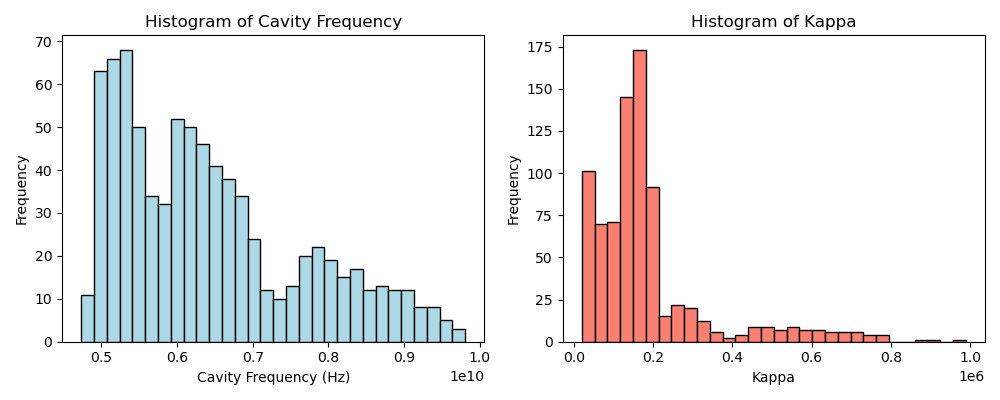

In [102]:
plt.figure(figsize=(10, 4))

# Histogram for Cavity Frequency
plt.subplot(1, 2, 1)
plt.hist(X['cavity_frequency'], bins=30, color='lightblue', edgecolor='black')
plt.title('Histogram of Cavity Frequency')
plt.xlabel('Cavity Frequency (Hz)')
plt.ylabel('Frequency')

# Histogram for Kappa
plt.subplot(1, 2, 2)
plt.hist(X['kappa'], bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of Kappa')
plt.xlabel('Kappa')
plt.ylabel('Frequency')

plt.tight_layout()
#plt.show()

In [103]:
plt.savefig('plots/unscaled_X_data.png')
plt.close()

Text(0, 0.5, 'Kappa')

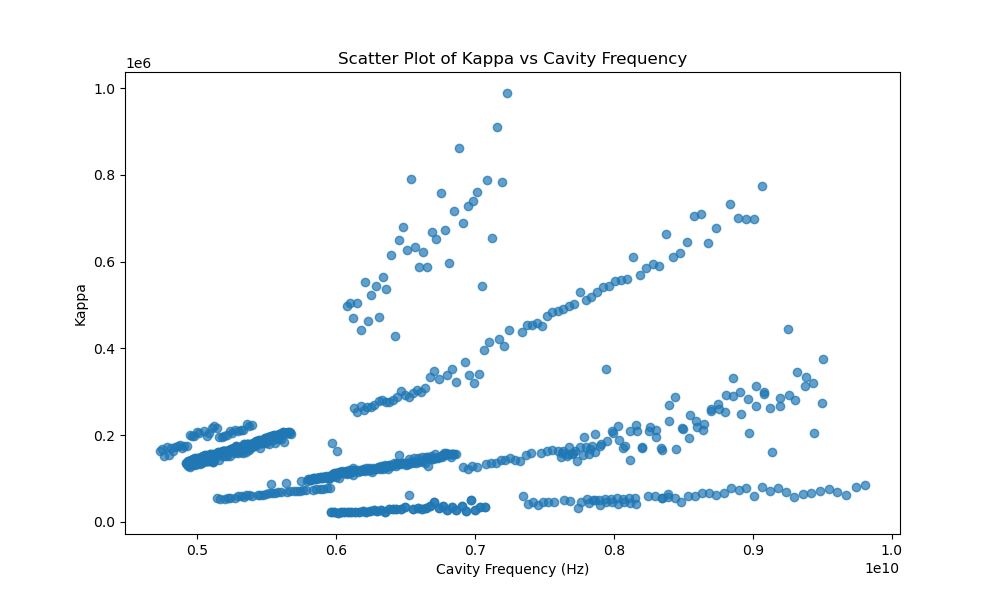

In [104]:
kappa_values = X['kappa']
cavity_frequency_values = X['cavity_frequency']

plt.figure(figsize=(10, 6))
plt.scatter(cavity_frequency_values, kappa_values, alpha=0.7)
plt.title('Scatter Plot of Kappa vs Cavity Frequency')
plt.xlabel('Cavity Frequency (Hz)')
plt.ylabel('Kappa')
#plt.grid(True)
#plt.show()

### Y data

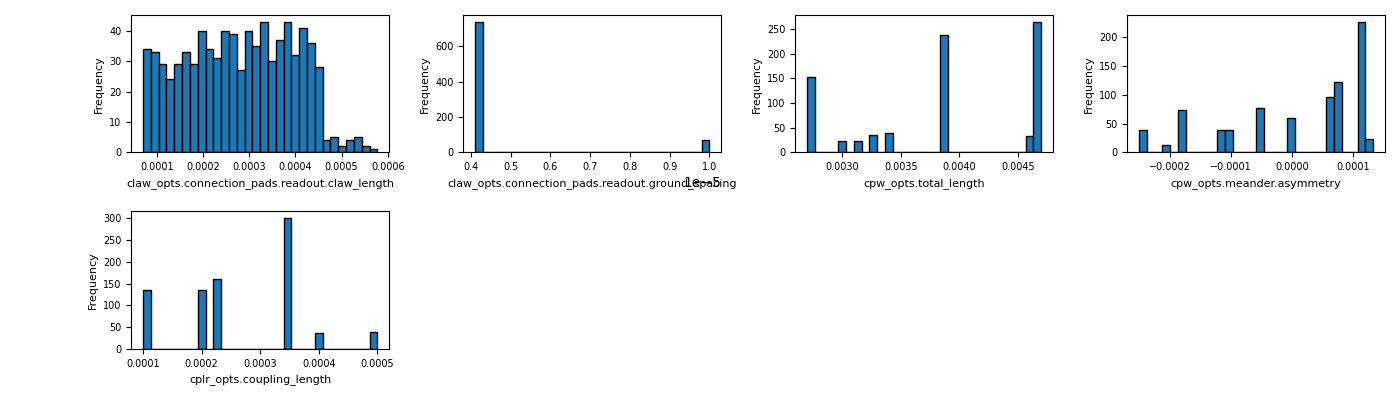

In [105]:
plt.close()
i=0
for y_value__encoding_format in y_numerical_removed_um_encoding_formats:
    num_cols = len(y_value__encoding_format.columns)
    num_rows = ((num_cols + 2) // 4) + 1
    
    plt.figure(figsize=(14, 2 * num_rows)) #Reduced figure size
    
    for n, col in enumerate(y_value__encoding_format.columns):
        try:
            plt.subplot(num_rows, 4, n + 1)
            plt.hist(y_value__encoding_format[col], bins=30, edgecolor='black')
            plt.xlabel(col.split('design_options.')[-1], fontsize=8) 
            plt.ylabel('Frequency', fontsize=8) 
            plt.tick_params(axis='both', which='major', labelsize=7) 
    
        except TypeError:
            print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")
    
    plt.tight_layout()
    plt.savefig(f'plots/unscaled_y_data_{y_encoding_format_names[i]}_encoding.png')
    plt.show()
    i+=1


### X vs Y correlation plots

In [106]:
i=0
for y_val in y_numerical_removed_um_encoding_formats:
    num_cols = len(y_val.columns)
    num_rows = ((num_cols + 2) // 4) + 1
    
    plt.figure(figsize=(14, 2 * num_rows)) 
    for n, col in enumerate(y_val.columns):
        try:
            plt.subplot(num_rows, 4, n + 1)
            plt.scatter(y_val[col], kappa_values, alpha=0.7) 
            plt.ylabel('Kappa', fontsize=8) 
            plt.xlabel(col.split('design_options.')[-1], fontsize=8) 
            plt.tick_params(axis='both', which='major', labelsize=7) 
        except TypeError:
            print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")
    
    plt.tight_layout()
    plt.savefig(f'plots/unscaled_y_exists__vs_kappa_correlation_{y_encoding_format_names[i]}_encoding.png')
    i+=1

In [107]:
i=0
for y_val in y_numerical_removed_um_encoding_formats:
    num_cols = len(y_val.columns)
    num_rows = ((num_cols + 2) // 4) + 1
    
    plt.figure(figsize=(14, 2 * num_rows)) 
    for n, col in enumerate(y_val.columns):
        try:
            plt.subplot(num_rows, 4, n + 1)
            plt.scatter(y_val[col], cavity_frequency_values, alpha=0.7) 
            plt.ylabel('Cavity Frequency', fontsize=8) 
            plt.xlabel(col.split('design_options.')[-1], fontsize=8) 
            plt.tick_params(axis='both', which='major', labelsize=7) 
        except TypeError:
            print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")
    
    plt.tight_layout()
    plt.savefig(f'plots/unscaled_y_value__vs_cavity_freq_correlation_{y_encoding_format_names[i]}_encoding.png')
    #plt.show()
    i+=1
    
plt.close()

## Augment 

### Scale X

Scale kappa and frequency to be between 0 and 1

In [108]:
X_scaled = X.copy()
for col in X_scaled.columns:
    scaler = MinMaxScaler()
    X_scaled[col] = scaler.fit_transform(X_scaled[[col]]) #only fit to this column
    joblib.dump(scaler, f'scalers/scaler_X_{col}.save') #save for later

In [109]:
# Check the scaling
display(X_scaled)

,cavity_frequency,kappa
0,0.121977,0.145357
1,0.722732,0.256164
2,0.781039,0.243216
3,0.371106,0.010447
4,0.641386,0.194095
...,...,...
805,0.543325,0.026499
806,0.535978,0.019098
807,0.528756,0.027214
808,0.521443,0.021875


### Scale y

In [110]:
y_numerical_removed_um_encoding_formats_scaled = []

i=0
for y_numerical_removed_um_encoding_format in y_numerical_removed_um_encoding_formats:
    y_value__scaled = y_numerical_removed_um_encoding_format.copy()
    for col in y_value__scaled.columns:
        scaler = MinMaxScaler()
        y_value__scaled[col] = scaler.fit_transform(y_value__scaled[[col]]) #only fit to this column
        joblib.dump(scaler, f'scalers/scaler_y_value__{col}_{y_encoding_format_names[i]}_encoding.save') #save for later
    y_numerical_removed_um_encoding_formats_scaled.append(y_value__scaled)
    i+=1

### Plot Scaled Data

### X

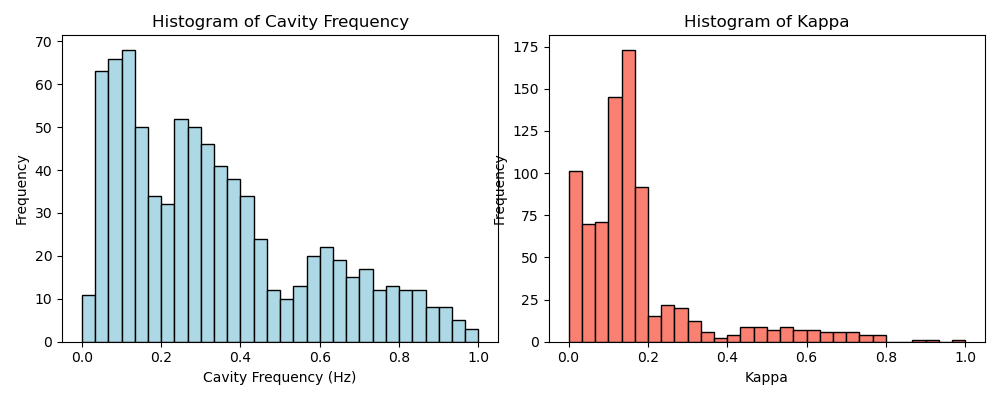

In [111]:
plt.figure(figsize=(10, 4))

# Histogram for Cavity Frequency
plt.subplot(1, 2, 1)
plt.hist(X_scaled['cavity_frequency'], bins=30, color='lightblue', edgecolor='black')
plt.title('Histogram of Cavity Frequency')
plt.xlabel('Cavity Frequency (Hz)')
plt.ylabel('Frequency')

# Histogram for Kappa
plt.subplot(1, 2, 2)
plt.hist(X_scaled['kappa'], bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of Kappa')
plt.xlabel('Kappa')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [112]:
plt.savefig('plots/scaled_X_data.png')
plt.close()

### Y

/tmp/ipykernel_3454620/1296131860.py:20: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


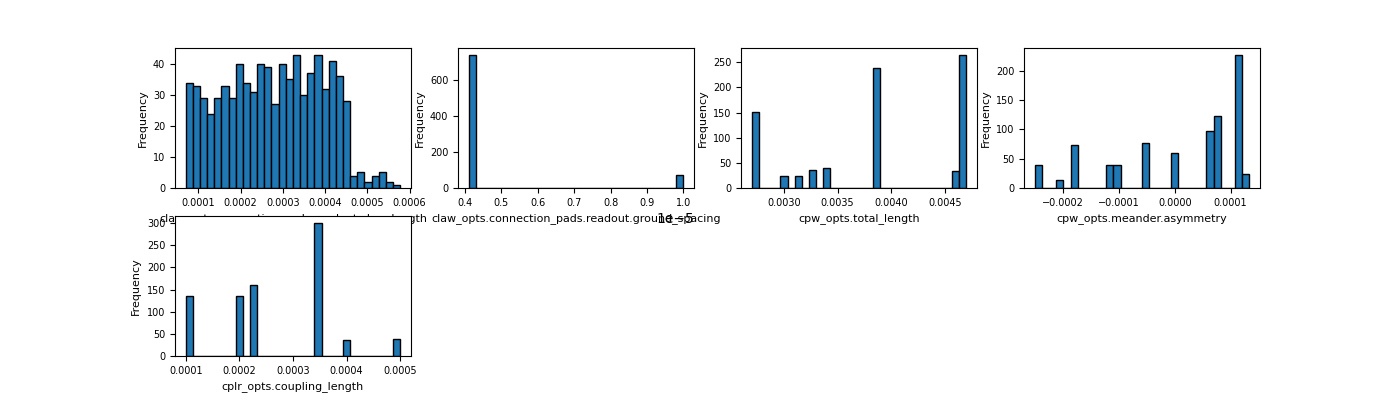

In [113]:
i=0
for y_val in y_numerical_removed_um_encoding_formats:

    num_cols = len(y_val.columns)
    num_rows = ((num_cols + 2) // 4) + 1
    
    plt.figure(figsize=(14, 2 * num_rows)) #Reduced figure size
    
    for n, col in enumerate(y_val.columns):
        try:
            plt.subplot(num_rows, 4, n + 1)
            plt.hist(y_val[col], bins=30, edgecolor='black')
            plt.xlabel(col.split('design_options.')[-1], fontsize=8) 
            plt.ylabel('Frequency', fontsize=8) 
            plt.tick_params(axis='both', which='major', labelsize=7) 
    
        except TypeError:
            print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")
    
    plt.tight_layout()
    plt.savefig(f'plots/scaled_y_value__data_{y_encoding_format_names[i]}_encoding.png')
    plt.show()
    i+=1


In [114]:
plt.close()

### Unscale to make sure you can recreate original values with saved scaler

### Unscale X

In [115]:
X_orig = X_scaled.copy()
for col in X_scaled.columns:
    scaler = joblib.load(f'scalers/scaler_X_{col}.save')
    X_orig[col] = scaler.inverse_transform(X_scaled[[col]]) 

display(X_orig)

,cavity_frequency,kappa
0,5.353550e+09,161106.598429
1,8.399241e+09,268412.116632
2,8.694845e+09,255873.654612
3,6.616574e+09,30459.761161
4,7.986835e+09,208304.221064
...,...,...
805,7.489689e+09,46004.713078
806,7.452442e+09,38837.211205
807,7.415826e+09,46696.417529
808,7.378752e+09,41526.048615


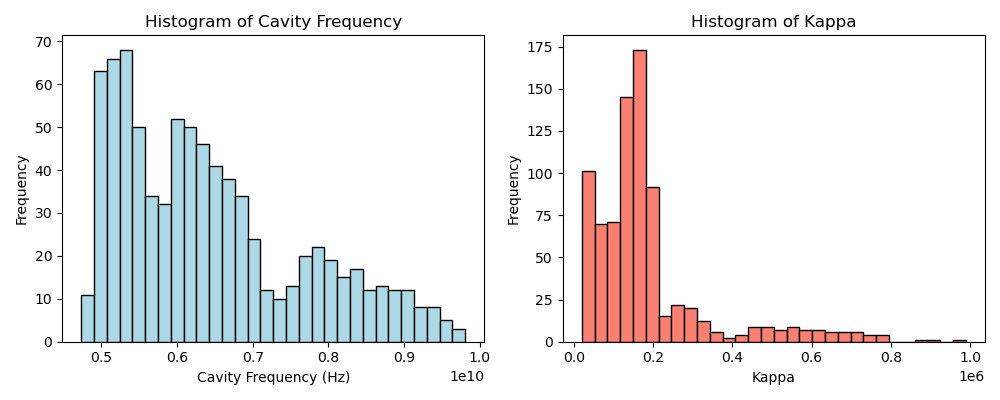

In [116]:
#plot again to see if you get same histgrams as pre-scaling
plt.figure(figsize=(10, 4))

# Histogram for Cavity Frequency
plt.subplot(1, 2, 1)
plt.hist(X_orig['cavity_frequency'], bins=30, color='lightblue', edgecolor='black')
plt.title('Histogram of Cavity Frequency')
plt.xlabel('Cavity Frequency (Hz)')
plt.ylabel('Frequency')

# Histogram for Kappa
plt.subplot(1, 2, 2)
plt.hist(X_orig['kappa'], bins=30, color='salmon', edgecolor='black')
plt.title('Histogram of Kappa')
plt.xlabel('Kappa')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Unscale Y

In [117]:
y_orig_value__encoding_formats = []

i=0
for y_value__scaled in y_numerical_removed_um_encoding_formats:
    y_orig = y_value__scaled.copy()
    for col in y_value__scaled.columns:
        scaler = joblib.load(f'scalers/scaler_y_value__{col}_{y_encoding_format_names[i]}_encoding.save')
        y_orig[col] = scaler.inverse_transform(y_value__scaled[[col]])
    y_orig_value__encoding_formats.append(y_orig)
    print('Encoding Type: ', y_encoding_format_names[i])
    display(y_orig)
    print('\n')
    i+=1

Encoding Type:  one_hot


,design_options.claw_opts.connection_pads.readout.claw_length,design_options.claw_opts.connection_pads.readout.ground_spacing,design_options.cpw_opts.total_length,design_options.cpw_opts.meander.asymmetry,design_options.cplr_opts.coupling_length
0,0.00007,0.000004,0.002709,-0.00025,0.0001
1,0.00007,0.000004,0.002705,-0.00025,0.0001
2,0.00007,0.000004,0.002705,-0.00025,0.0001
3,0.00007,0.000004,0.002708,-0.00025,0.0001
4,0.00007,0.000004,0.002705,-0.00025,0.0001
...,...,...,...,...,...
805,0.00007,0.000004,0.002706,-0.00025,0.0001
806,0.00007,0.000004,0.002706,-0.00025,0.0001
807,0.00007,0.000004,0.002706,-0.00025,0.0001
808,0.00007,0.000004,0.002706,-0.00025,0.0001


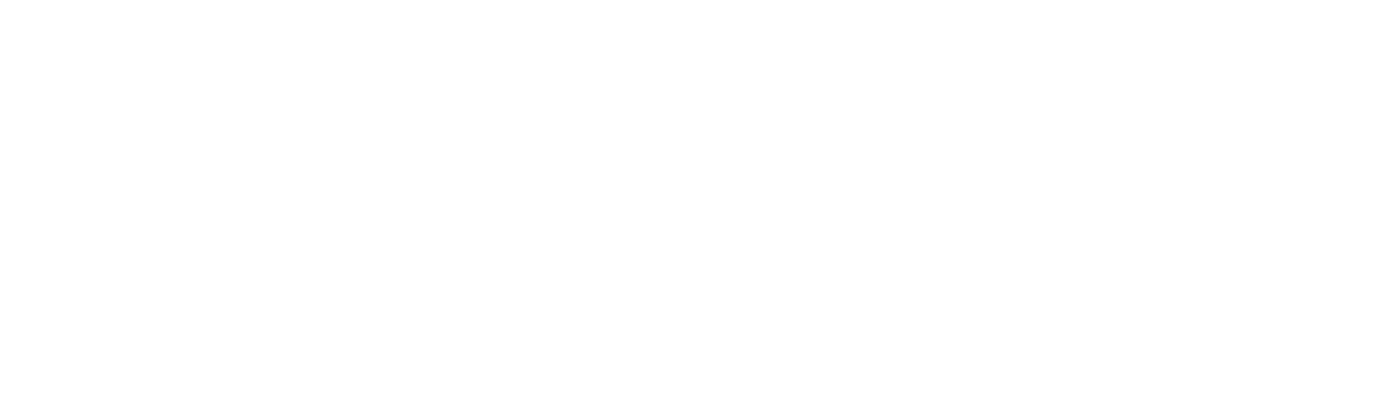

In [118]:
i=0
for y_orig in y_numerical_removed_um_encoding_formats:
    num_cols = len(y_orig.columns)
    num_rows = ((num_cols + 2) // 4) + 1
    
    plt.figure(figsize=(14, 2 * num_rows)) #Reduced figure size
    
    for i, col in enumerate(y_orig.columns):
        try:
            plt.subplot(num_rows, 4, i + 1)
            plt.hist(y_orig[col], bins=30, edgecolor='black')
            plt.xlabel(col.split('design_options.')[-1], fontsize=8) 
            plt.ylabel('Frequency', fontsize=8) 
            plt.tick_params(axis='both', which='major', labelsize=7) 
    
        except TypeError:
            print(f"Warning: Column '{col}' is not numeric and cannot be plotted.")
    
    plt.tight_layout()
    plt.show()
    i+=1

## Split

In [119]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
print('Tensorflow ver.', tf.__version__)

Tensorflow ver. 2.20.0


Dataset split is 70%-30% training-validation and test sets. We use a constant state (seed) for reproducible splits across multiple runs.

In [122]:
# Unscaled data split
if 'one hot' in ENCODING_TYPE:
    X_train, X_val_test, y_train_one_hot_encoding, y_val_test_one_hot_encoding = train_test_split(
        X, y_encoding_formats[0], test_size=0.3, random_state=42, shuffle=True
    ) # 70% train, 30% val/test
    X_val, X_test, y_val_one_hot_encoding, y_test_one_hot_encoding = train_test_split(
        X_val_test, y_val_test_one_hot_encoding, test_size=0.5, random_state=42, shuffle=True
    ) # Split the 30% into 15% val, 15% test

elif 'Linear' in ENCODING_TYPE:
    X_train, X_val_test, y_train_linear_encoding, y_val_test_linear_encoding = train_test_split(
        X, y_encoding_formats[1], test_size=0.3, random_state=42, shuffle=True
    )
    X_val, X_test, y_val_linear_encoding, y_test_linear_encoding = train_test_split(
        X_val_test, y_val_test_linear_encoding, test_size=0.5, random_state=42, shuffle=True
    )
elif 'Try Both' in ENCODING_TYPE:
    X_train_one_hot_encoding, X_val_test_one_hot_encoding, y_train_one_hot_encoding, y_val_test_one_hot_encoding = train_test_split(
        X, y_encoding_formats[0], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_one_hot_encoding, X_test_one_hot_encoding, y_val_one_hot_encoding, y_test_one_hot_encoding = train_test_split(
        X_val_test_one_hot_encoding, y_val_test_one_hot_encoding, test_size=0.5, random_state=42, shuffle=True
    )
    X_train_linear_encoding, X_val_test_linear_encoding, y_train_linear_encoding, y_val_test_linear_encoding = train_test_split(
        X, y_encoding_formats[1], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_linear_encoding, X_test_linear_encoding, y_val_linear_encoding, y_test_linear_encoding = train_test_split(
        X_val_test_linear_encoding, y_val_test_linear_encoding, test_size=0.5, random_state=42, shuffle=True
    )

## Scaled data split
if 'one hot' in ENCODING_TYPE:
    X_train_scaled, X_val_test_scaled, y_train_scaled_one_hot_encoding, y_val_test_scaled_one_hot_encoding = train_test_split(
        X_scaled, y_numerical_removed_um_encoding_formats_scaled[0], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_scaled, X_test_scaled, y_val_scaled_one_hot_encoding, y_test_scaled_one_hot_encoding = train_test_split(
        X_val_test_scaled, y_val_test_scaled_one_hot_encoding, test_size=0.5, random_state=42, shuffle=True
    )

elif 'Linear' in ENCODING_TYPE:
    X_train_scaled, X_val_test_scaled, y_train_scaled_linear_encoding, y_val_test_scaled_linear_encoding = train_test_split(
        X_scaled, y_numerical_removed_um_encoding_formats_scaled[1], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_scaled, X_test_scaled, y_val_scaled_linear_encoding, y_test_scaled_linear_encoding = train_test_split(
        X_val_test_scaled, y_val_test_scaled_linear_encoding, test_size=0.5, random_state=42, shuffle=True
    )

elif 'Try Both' in ENCODING_TYPE:
    # one-hot
    X_train_scaled_one_hot_encoding, X_val_test_scaled_one_hot_encoding, y_train_scaled_one_hot_encoding, y_val_test_scaled_one_hot_encoding = train_test_split(
        X_scaled, y_numerical_removed_um_encoding_formats_scaled[0], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_scaled_one_hot_encoding, X_test_scaled_one_hot_encoding, y_val_scaled_one_hot_encoding, y_test_scaled_one_hot_encoding = train_test_split(
        X_val_test_scaled_one_hot_encoding, y_val_test_scaled_one_hot_encoding, test_size=0.5, random_state=42, shuffle=True
    )

    # linear
    X_train_scaled_linear_encoding, X_val_test_scaled_linear_encoding, y_train_scaled_linear_encoding, y_val_test_scaled_linear_encoding = train_test_split(
        X_scaled, y_numerical_removed_um_encoding_formats_scaled[1], test_size=0.3, random_state=42, shuffle=True
    )
    X_val_scaled_linear_encoding, X_test_scaled_linear_encoding, y_val_scaled_linear_encoding, y_test_scaled_linear_encoding = train_test_split(
        X_val_test_scaled_linear_encoding, y_val_test_scaled_linear_encoding, test_size=0.5, random_state=42, shuffle=True
    )


In [123]:
#unscaled
if 'one hot' in ENCODING_TYPE:
    total = y_train_one_hot_encoding.shape[0] + y_test_one_hot_encoding.shape[0] + y_val_one_hot_encoding.shape[0]
    print('---------------------------------------')
    print('Train one-hot encoding set shape: {}, {:.2f}%'.format(y_train_one_hot_encoding.shape, (y_train_one_hot_encoding.shape[0]*100.)/total))
    print('Validation one-hot encoding set shape: {}, {:.2f}%'.format(y_val_one_hot_encoding.shape, (y_val_one_hot_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_one_hot_encoding.shape, (y_test_one_hot_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
elif 'Linear' in ENCODING_TYPE:
    total = y_train_linear_encoding.shape[0] + y_test_linear_encoding.shape[0] + y_val_linear_encoding.shape[0]
    print('---------------------------------------')
    print('Train linear encoding set shape: {}, {:.2f}%'.format(y_train_linear_encoding.shape, (y_train_linear_encoding.shape[0]*100.)/total))
    print('Validation linear encoding set shape: {}, {:.2f}%'.format(y_val_linear_encoding.shape, (y_val_linear_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_linear_encoding.shape, (y_test_linear_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
elif 'Try Both' in ENCODING_TYPE:
    total = y_train_one_hot_encoding.shape[0] + y_test_one_hot_encoding.shape[0] + y_val_one_hot_encoding.shape[0]
    print('---------------------------------------')
    print('Train one-hot encoding set shape: {}, {:.2f}%'.format(y_train_one_hot_encoding.shape, (y_train_one_hot_encoding.shape[0]*100.)/total))
    print('Validation one-hot encoding set shape: {}, {:.2f}%'.format(y_val_one_hot_encoding.shape, (y_val_one_hot_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_one_hot_encoding.shape, (y_test_one_hot_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
    
    total = y_train_linear_encoding.shape[0] + y_test_linear_encoding.shape[0] + y_val_linear_encoding.shape[0]
    print('---------------------------------------')
    print('Train linear encoding set shape: {}, {:.2f}%'.format(y_train_linear_encoding.shape, (y_train_linear_encoding.shape[0]*100.)/total))
    print('Validation linear encoding set shape: {}, {:.2f}%'.format(y_val_linear_encoding.shape, (y_val_linear_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_linear_encoding.shape, (y_test_linear_encoding.shape[0]*100.)/total))
    print('---------------------------------------')

---------------------------------------
Train one-hot encoding set shape: (567, 5), 70.00%
Validation one-hot encoding set shape: (121, 5), 14.94%
Test set shape:                 (122, 5), 15.06%
---------------------------------------


In [124]:
#scaled
if 'one hot' in ENCODING_TYPE:
    total = y_train_scaled_one_hot_encoding.shape[0] + y_test_scaled_one_hot_encoding.shape[0] + y_val_scaled_one_hot_encoding.shape[0]
    print('---------------------------------------')
    print('Train one-hot encoding set shape: {}, {:.2f}%'.format(y_train_scaled_one_hot_encoding.shape, (y_train_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('Validation one-hot encoding set shape: {}, {:.2f}%'.format(y_val_scaled_one_hot_encoding.shape, (y_val_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_scaled_one_hot_encoding.shape, (y_test_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
elif 'Linear' in ENCODING_TYPE:
    total = y_train_scaled_linear_encoding.shape[0] + y_test_scaled_linear_encoding.shape[0] + y_val_scaled_linear_encoding.shape[0]
    print('---------------------------------------')
    print('Train linear encoding set shape: {}, {:.2f}%'.format(y_train_scaled_linear_encoding.shape, (y_train_scaled_linear_encoding.shape[0]*100.)/total))
    print('Validation linear encoding set shape: {}, {:.2f}%'.format(y_val_scaled_linear_encoding.shape, (y_val_scaled_linear_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_scaled_linear_encoding.shape, (y_test_scaled_linear_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
elif 'Try Both' in ENCODING_TYPE:
    total = y_train_scaled_one_hot_encoding.shape[0] + y_test_scaled_one_hot_encoding.shape[0] + y_val_scaled_one_hot_encoding.shape[0]
    print('---------------------------------------')
    print('Train one-hot encoding set shape: {}, {:.2f}%'.format(y_train_scaled_one_hot_encoding.shape, (y_train_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('Validation one-hot encoding set shape: {}, {:.2f}%'.format(y_val_scaled_one_hot_encoding.shape, (y_val_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_scaled_one_hot_encoding.shape, (y_test_scaled_one_hot_encoding.shape[0]*100.)/total))
    print('---------------------------------------')
    
    total = y_train_scaled_linear_encoding.shape[0] + y_test_scaled_linear_encoding.shape[0] + y_val_scaled_linear_encoding.shape[0]
    print('---------------------------------------')
    print('Train linear encoding set shape: {}, {:.2f}%'.format(y_train_scaled_linear_encoding.shape, (y_train_scaled_linear_encoding.shape[0]*100.)/total))
    print('Validation linear encoding set shape: {}, {:.2f}%'.format(y_val_scaled_linear_encoding.shape, (y_val_scaled_linear_encoding.shape[0]*100.)/total))
    print('Test set shape:                 {}, {:.2f}%'.format(y_test_scaled_linear_encoding.shape, (y_test_scaled_linear_encoding.shape[0]*100.)/total))
    print('---------------------------------------')

---------------------------------------
Train one-hot encoding set shape: (567, 5), 70.00%
Validation one-hot encoding set shape: (121, 5), 14.94%
Test set shape:                 (122, 5), 15.06%
---------------------------------------


In [125]:
if 'Try Both' not in ENCODING_TYPE:
    display(X_train_scaled) #can check this in next script as well after loading to make sure it matches
    display(X_val_scaled)
else:
    display(X_train_scaled_one_hot_encoding) 
    display(X_val_scaled_one_hot_encoding)
    
    display(X_train_scaled_linear_encoding) 
    display(X_val_scaled_linear_encoding)

,cavity_frequency,kappa
777,0.496935,0.132124
436,0.277130,0.100609
132,0.676927,0.195902
506,0.153839,0.174880
266,0.251704,0.000000
...,...,...
71,0.441101,0.029978
106,0.461518,0.015372
270,0.454547,0.015148
435,0.282328,0.103247


,cavity_frequency,kappa
351,0.876424,0.058505
758,0.012193,0.137984
605,0.064319,0.124569
352,0.865056,0.051322
730,0.113998,0.197416
...,...,...
97,0.239630,0.081140
259,0.287346,0.004451
709,0.358681,0.286592
580,0.161291,0.184816


### Save

Save the split data set for future reference

In [126]:
!rm -f $DATA_DIR/npy/*npy

In [127]:
#unscaled
if 'one hot' in ENCODING_TYPE:
    np.save('{}/npy/x_train_one_hot_encoding.npy'.format(DATA_DIR), X_train)
    np.save('{}/npy/x_val_one_hot_encoding.npy'.format(DATA_DIR), X_val)
    np.save('{}/npy/x_test_one_hot_encoding.npy'.format(DATA_DIR), X_test)
    
    np.save('{}/npy/y_train_one_hot_encoding.npy'.format(DATA_DIR), y_train_one_hot_encoding)
    np.save('{}/npy/y_val_one_hot_encoding.npy'.format(DATA_DIR), y_val_one_hot_encoding)
    np.save('{}/npy/y_test_one_hot_encoding.npy'.format(DATA_DIR), y_test_one_hot_encoding)
elif 'Linear' in ENCODING_TYPE:
    np.save('{}/npy/x_train_linear_encoding.npy'.format(DATA_DIR), X_train)
    np.save('{}/npy/x_val_linear_encoding.npy'.format(DATA_DIR), X_val)
    np.save('{}/npy/x_test_linear_encoding.npy'.format(DATA_DIR), X_test)
    np.save('{}/npy/y_train_linear_encoding.npy'.format(DATA_DIR), y_train_linear_encoding)
    np.save('{}/npy/y_val_linear_encoding.npy'.format(DATA_DIR), y_val_linear_encoding)
    np.save('{}/npy/y_test_linear_encoding.npy'.format(DATA_DIR), y_test_linear_encoding)
elif 'Try Both' in ENCODING_TYPE:
    np.save('{}/npy/x_train_one_hot_encoding.npy'.format(DATA_DIR), X_train_one_hot_encoding)
    np.save('{}/npy/x_val_one_hot_encoding.npy'.format(DATA_DIR), X_val_one_hot_encoding)
    np.save('{}/npy/x_test_one_hot_encoding.npy'.format(DATA_DIR), X_test_one_hot_encoding)
    
    np.save('{}/npy/x_train_linear_encoding.npy'.format(DATA_DIR), X_train_linear_encoding)
    np.save('{}/npy/x_val_linear_encoding.npy'.format(DATA_DIR), X_val_linear_encoding)
    np.save('{}/npy/x_test_linear_encoding.npy'.format(DATA_DIR), X_test_linear_encoding)
    
    np.save('{}/npy/y_train_one_hot_encoding.npy'.format(DATA_DIR), y_train_one_hot_encoding)
    np.save('{}/npy/y_val_one_hot_encoding.npy'.format(DATA_DIR), y_val_one_hot_encoding)
    np.save('{}/npy/y_test_one_hot_encoding.npy'.format(DATA_DIR), y_test_one_hot_encoding)
    
    np.save('{}/npy/y_train_linear_encoding.npy'.format(DATA_DIR), y_train_linear_encoding)
    np.save('{}/npy/y_val_linear_encoding.npy'.format(DATA_DIR), y_val_linear_encoding)
    np.save('{}/npy/y_test_linear_encoding.npy'.format(DATA_DIR), y_test_linear_encoding)
    
print('Data saved in: {}/npy'.format(DATA_DIR))

Data saved in: data/npy


In [128]:
#scaled
if 'one hot' in ENCODING_TYPE:
    np.save('{}/npy/x_train_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_train_scaled)
    np.save('{}/npy/x_val_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_val_scaled)
    np.save('{}/npy/x_test_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_test_scaled)
    
    np.save('{}/npy/y_train_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_train_scaled_one_hot_encoding)
    np.save('{}/npy/y_val_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_val_scaled_one_hot_encoding)
    np.save('{}/npy/y_test_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_test_scaled_one_hot_encoding)

elif 'Linear' in ENCODING_TYPE:
    np.save('{}/npy/x_train_linear_encoding_augmented.npy'.format(DATA_DIR), X_train_scaled)
    np.save('{}/npy/x_val_linear_encoding_augmented.npy'.format(DATA_DIR), X_val_scaled)
    np.save('{}/npy/x_test_linear_encoding_augmented.npy'.format(DATA_DIR), X_test_scaled)
    
    np.save('{}/npy/y_train_linear_encoding_augmented.npy'.format(DATA_DIR), y_train_scaled_linear_encoding) 
    np.save('{}/npy/y_val_linear_encoding_augmented.npy'.format(DATA_DIR), y_val_scaled_linear_encoding)
    np.save('{}/npy/y_test_linear_encoding_augmented.npy'.format(DATA_DIR), y_test_scaled_linear_encoding)

elif 'Try Both' in ENCODING_TYPE:
    np.save('{}/npy/x_train_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_train_scaled_one_hot_encoding)
    np.save('{}/npy/x_val_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_val_scaled_one_hot_encoding)
    np.save('{}/npy/x_test_one_hot_encoding_augmented.npy'.format(DATA_DIR), X_test_scaled_one_hot_encoding)
    
    np.save('{}/npy/x_train_linear_encoding_augmented.npy'.format(DATA_DIR), X_train_scaled_linear_encoding)
    np.save('{}/npy/x_val_linear_encoding_augmented.npy'.format(DATA_DIR), X_val_scaled_linear_encoding)
    np.save('{}/npy/x_test_linear_encoding_augmented.npy'.format(DATA_DIR), X_test_scaled_linear_encoding)
    
    np.save('{}/npy/y_train_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_train_scaled_one_hot_encoding)
    np.save('{}/npy/y_val_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_val_scaled_one_hot_encoding)
    np.save('{}/npy/y_test_one_hot_encoding_augmented.npy'.format(DATA_DIR), y_test_scaled_one_hot_encoding)
    
    np.save('{}/npy/y_train_linear_encoding_augmented.npy'.format(DATA_DIR), y_train_scaled_linear_encoding)
    np.save('{}/npy/y_val_linear_encoding_augmented.npy'.format(DATA_DIR), y_val_scaled_linear_encoding)
    np.save('{}/npy/y_test_linear_encoding_augmented.npy'.format(DATA_DIR), y_test_scaled_linear_encoding)
    
print('Data saved in: {}/npy'.format(DATA_DIR))

Data saved in: data/npy


In [129]:
!ls $DATA_DIR/npy/*npy

data/npy/x_test_one_hot_encoding_augmented.npy
data/npy/x_test_one_hot_encoding.npy
data/npy/x_train_one_hot_encoding_augmented.npy
data/npy/x_train_one_hot_encoding.npy
data/npy/x_val_one_hot_encoding_augmented.npy
data/npy/x_val_one_hot_encoding.npy
data/npy/y_test_one_hot_encoding_augmented.npy
data/npy/y_test_one_hot_encoding.npy
data/npy/y_train_one_hot_encoding_augmented.npy
data/npy/y_train_one_hot_encoding.npy
data/npy/y_val_one_hot_encoding_augmented.npy
data/npy/y_val_one_hot_encoding.npy


In [130]:
with open('X_names', 'w') as f:
        f.write('\n'.join(X.columns))